# ANALYSE

In [1]:
# Importation des librairies
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
sns.set_theme(style="whitegrid")

#1. Le top des constructeurs (Gael)

Nous souhaitons savoir ce qui se vend le plus.

In [2]:
df = pd.read_csv('tractors_cleaned.csv')
df.head()# Affichage des informations sur le DataFrame
df.info()# Affichage des statistiques descriptives
df.describe()# Affichage de la distribution des variables numérique

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 195 entries, 0 to 194
Data columns (total 10 columns):
 #   Column                Non-Null Count  Dtype 
---  ------                --------------  ----- 
 0   manufacturer          195 non-null    object
 1   Model                 195 non-null    object
 2   Condition             195 non-null    object
 3   Listing ID            195 non-null    object
 4   Update                195 non-null    object
 5   Year of construction  195 non-null    int64 
 6   Mileage               195 non-null    int64 
 7   price                 195 non-null    int64 
 8   ville                 195 non-null    object
 9   pays                  195 non-null    object
dtypes: int64(3), object(7)
memory usage: 15.4+ KB


,Year of construction,Mileage,price
count,195.000000,1.950000e+02,195.000000
mean,2019.441026,5.064748e+05,43832.876923
std,4.176562,2.850303e+05,33297.674822
min,2001.000000,6.000000e+00,7900.000000
25%,2018.000000,3.210730e+05,20175.000000
50%,2021.000000,4.703910e+05,32900.000000
75%,2022.000000,6.991715e+05,53850.000000
max,2026.000000,1.572883e+06,195331.000000


C:\Users\ACER\AppData\Local\Temp\ipykernel_6280\1224825241.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=top_manufacturers.values, y=top_manufacturers.index, palette="viridis")


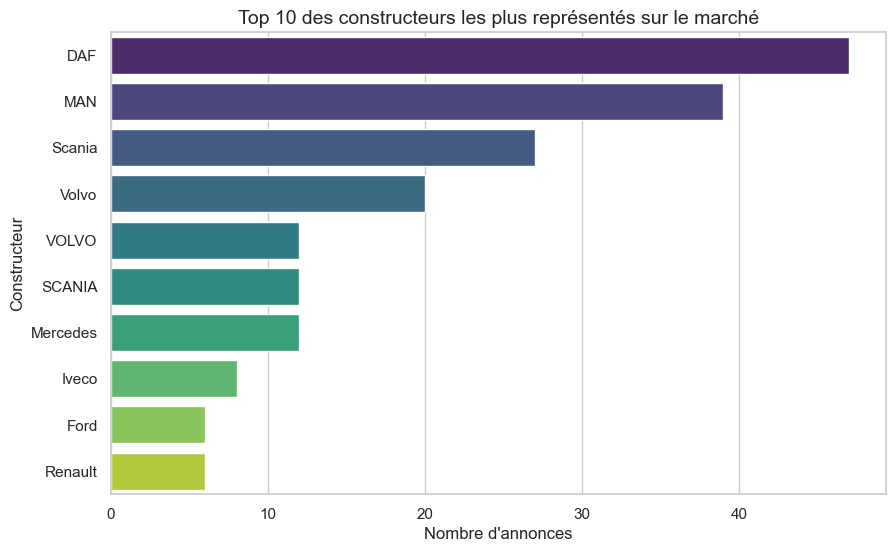

In [3]:
plt.figure(figsize=(10, 6))

# On isole le Top 10 pour garder un graphique lisible
top_manufacturers = df['manufacturer'].value_counts().nlargest(10)

# On fait un graphique horizontal (x et y inversés) pour lire les noms facilement
sns.barplot(x=top_manufacturers.values, y=top_manufacturers.index, palette="viridis")

plt.title('Top 10 des constructeurs les plus représentés sur le marché', fontsize=14)
plt.xlabel("Nombre d'annonces")
plt.ylabel('Constructeur')
plt.show()

Nous voyons clairement que le constructeur DAF est le top (c'est à dire à dire) le pus présenté sur le marché, suivi de MAN en seconde position en focntion du nombre d'annonces présentes sur le site.

#2. La distribution des prix (Amadou)

Visualiser la concentration du marché.

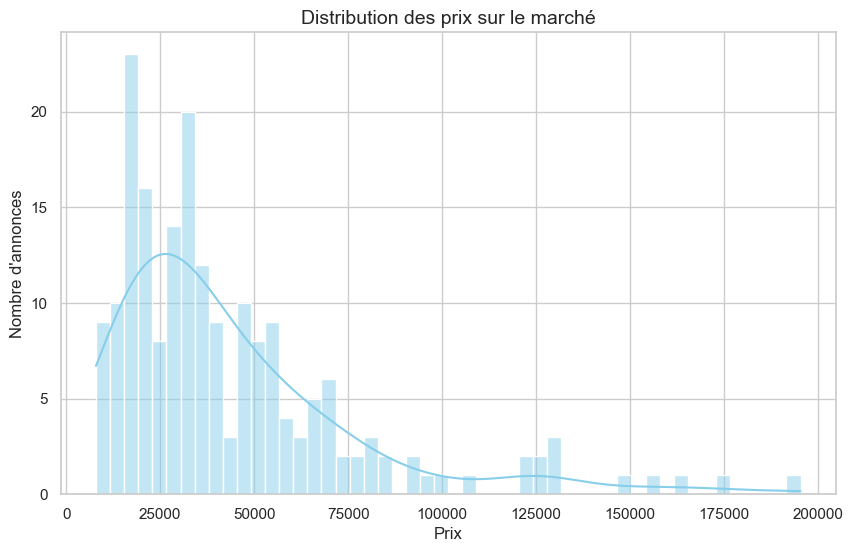

In [4]:
plt.figure(figsize=(10, 6))

# kde=True ajoute la petite courbe de tendance lissée par-dessus les barres
sns.histplot(data=df, x='price', bins=50, kde=True, color="skyblue")

plt.title('Distribution des prix sur le marché', fontsize=14)
plt.xlabel('Prix')
plt.ylabel("Nombre d'annonces")

# Astuce : Dé-commente la ligne ci-dessous si des annonces à 1 million d'euros écrasent ton graphique
# plt.xlim(0, 100000)

plt.show()

#3. L'impact du kilométrage sur le prix (Gwladys)

Mesure de la décote kilométrique pour tous les engins.

In [5]:
plt.figure(figsize=(10, 6))

# On ajoute 'hue' pour colorer les points selon l'état du véhicule (condition)
# alpha=0.6 rend les points légèrement transparents pour mieux voir les superpositions
sns.scatterplot(data=df, x='mileage', y='price', hue='condition', alpha=0.6, palette="Set2")

plt.title('Impact du kilométrage sur le prix', fontsize=14)
plt.xlabel('Kilométrage')
plt.ylabel('Prix')
plt.show()

ValueError: Could not interpret value `mileage` for `x`. An entry with this name does not appear in `data`.

<Figure size 1000x600 with 0 Axes>

#4. Comparaison des prix selon l'état (Pacifique)

Évaluation de la prime à la qualité.

In [6]:
plt.figure(figsize=(10, 6))

# Tu pourras adapter cette liste selon les vrais statuts présents dans ta base
order_conditions = ["Excellent", "Good", "Fair", "Needs repair"]

# On crée les boîtes à moustaches
sns.boxplot(data=df, x='condition', y='price', palette="pastel")

plt.title('Répartition des prix selon l\'état du véhicule', fontsize=14)
plt.xlabel('État (Condition)')
plt.ylabel('Prix')
plt.show()

ValueError: Could not interpret value `condition` for `x`. An entry with this name does not appear in `data`.

<Figure size 1000x600 with 0 Axes>

#5. La courbe d'évolution au regard des année (David)

Analyse de l'evolution du prix selon les années de construction

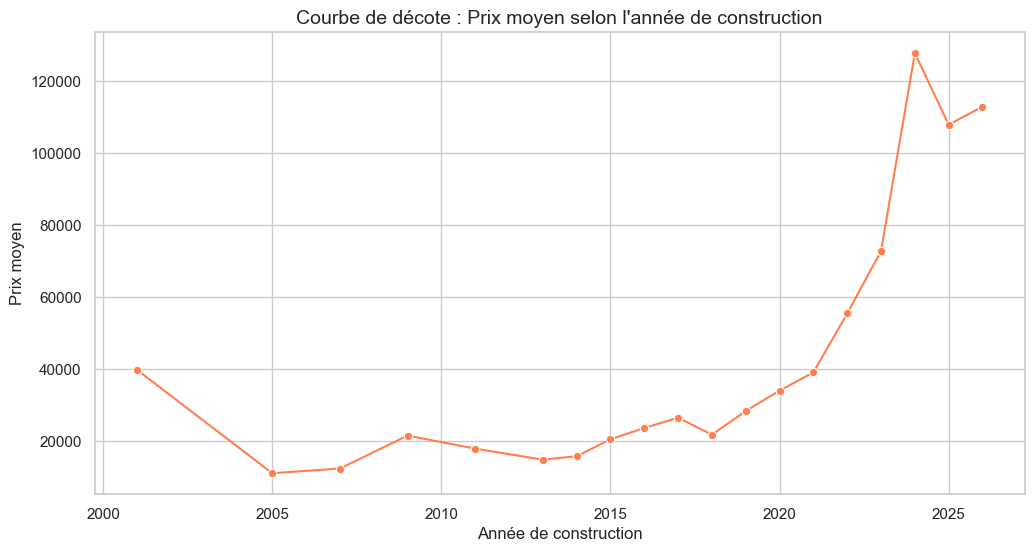

In [12]:
plt.figure(figsize=(12, 6))

# Étape intermédiaire cruciale : on doit grouper par année et calculer la moyenne des prix
prix_moyen_par_annee = df.groupby('Year of construction')['price'].mean().reset_index()

# On trace la ligne
sns.lineplot(data=prix_moyen_par_annee, x='Year of construction', y='price', marker='o', color="coral")

plt.title('Courbe de décote : Prix moyen selon l\'année de construction', fontsize=14)
plt.xlabel('Année de construction')
plt.ylabel('Prix moyen')
plt.show()

Le graphique parle de lui-même. Entre les années 2000 et 2005 le prix moyen a diminué mais juste après cela, les prix n'ont fait que croître; de manière exponentielle à partir de 2018 jusqu'à exploser à partir de 2023 et atteindre un pic en 2024 avant de connaitre une relaxation. Ceci pourrait être attribué à l'évolution dans le domaine de la fabrication de ces engins. En effet, des engins bien plus performants coûtent naturellement plus cher; ce qui pourrait être la cause de ces flustuations du prix moyen des tractors.